# Importing Libraries and functions

In [1]:
import pandas as pd
import numpy as np

# To save and load our models
import pickle

# To plot 
import matplotlib.pyplot as plt
import seaborn  as sns

# To training the model
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble        import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap
from sklearn.inspection import permutation_importance

# Fairlearn 
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
from fairlearn.metrics import equalized_odds_difference,  equalized_odds_ratio
from fairlearn.metrics import selection_rate, true_negative_rate, true_positive_rate, false_positive_rate, false_negative_rate
from fairlearn.metrics import MetricFrame

# Personalized functions
from functions import compute_metrics, fpr, fnr, tmo

# Importing the data

In [2]:
df_trainval = pd.read_csv('CSV_TRAIN.csv', sep = ";")
df_test     = pd.read_csv('CSV_TEST.csv',  sep = ";")

df_trainval['TARGET'] = 1 - df_trainval["DEFAULT"]
df_test['TARGET']     = 1 - df_test["DEFAULT"]

In [3]:
df_trainval_nonulls = df_trainval.dropna().reset_index(drop=True)
df_test_nonulls     = df_test.dropna().reset_index(drop=True)

In [4]:
print(f"After dropping {df_trainval.shape[0] - df_trainval_nonulls.shape[0]} instances with some nulls, the training set has {df_trainval_nonulls.shape[0]} observations")
print(f"After dropping {df_test.shape[0]     - df_test_nonulls.shape[0]} instances with some nulls, the test set has {df_test_nonulls.shape[0]} observations")

After dropping 25 instances with some nulls, the training set has 20029 observations
After dropping 10 instances with some nulls, the test set has 5726 observations


In [5]:
X_trainval   = df_trainval_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_trainval   = df_trainval_nonulls['TARGET']

X_train, X_val, Y_train, Y_val = train_test_split(X_trainval, Y_trainval, test_size = 0.25, random_state = 1)

X_test   = df_test_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_test   = df_test_nonulls['TARGET']


PF1_train = X_train['PF1']
PF2_train = X_train['PF2']

PF1_val   = X_val['PF1']
PF2_val   = X_val['PF2']

PF1_test  = X_test['PF1']
PF2_test = X_test['PF2']

X_train = X_train.drop(['PF1', 'PF2'], axis = 1)
X_val   = X_val.drop(['PF1', 'PF2'], axis = 1)
X_test  = X_test.drop(['PF1', 'PF2'], axis = 1)

In [6]:
print(f" The dataset we will use for training   has {X_train.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for validation has {X_val.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for test       has {X_test.shape[0]} observations and {X_test.shape[1]} features.")

 The dataset we will use for training   has 15021 observations and 16 features.
 The dataset we will use for validation has 5008 observations and 16 features.
 The dataset we will use for test       has 5726 observations and 16 features.


# Fine tunning

We will use XGBoost as our algorithm to create the score. We will use GridSearch to search the optimal hyperparameters.

In [7]:
param_grid = {
    'max_depth': [2, 4],
    'learning_rate': [0.01, 0.025, 0.05],
    'n_estimators': [500, 1000],
    'gamma': [10, 25],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.75],
    'min_child_weight': [8, 32],
    'early_stopping_rounds': [50]}

In [8]:
xgb = XGBClassifier(random_state=1)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=4, scoring='roc_auc', n_jobs=2, verbose=1, return_train_score=True)

# Calling grid_search on our data
grid_search.fit(X_train, Y_train)

# Save the results
cv_results = grid_search.cv_results_

# We create a df with the AUC obtained in train and test for different hyperparameters. 
results_df = pd.DataFrame({'params': cv_results['params'],
                           'mean_train_gini': 2*cv_results['mean_train_score']-1,
                           'mean_test_gini': 2*cv_results['mean_test_score']-1,
                           'gini_diff': (2*cv_results['mean_train_score'] -1) - (2*cv_results['mean_test_score']-1)})

Fitting 4 folds for each of 96 candidates, totalling 384 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  2.3min
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed: 10.1min
[Parallel(n_jobs=2)]: Done 384 out of 384 | elapsed: 19.8min finished


From those who do not present significant overfitting, we will choose the one with a higher AUC in the test part of the cross-validation.

In [9]:
results_df_filter = results_df.sort_values('mean_test_gini', ascending=False)
results_df_filter = results_df_filter[results_df_filter['gini_diff']<0.03]
results_df_filter.head()

,params,mean_train_gini,mean_test_gini,gini_diff
86,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.499452,0.473546,0.025906
82,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.499635,0.473444,0.026191
78,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.501646,0.472517,0.029130
70,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.496685,0.471161,0.025524
80,"{'colsample_bytree': 0.75, 'early_stopping_rou...",0.497117,0.470861,0.026256


In [10]:
best_hyperparams = results_df_filter.sort_values('mean_test_gini', ascending=False)\
                    [results_df_filter['gini_diff']<0.03].iloc[0, 0]
print(best_hyperparams)

{'colsample_bytree': 0.75, 'early_stopping_rounds': 50, 'gamma': 25, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 32, 'n_estimators': 1000, 'subsample': 0.8}


Once we have the best hyperparameters, we train the model using those and we save it.

In [11]:
best_xgb = XGBClassifier(**best_hyperparams, random_state=1, n_jobs=2)
best_xgb.fit(X_train, Y_train)


XGBClassifier(colsample_bytree=0.75, early_stopping_rounds=50, gamma=25,
              learning_rate=0.05, max_depth=2, min_child_weight=32,
              n_estimators=1000, n_jobs=2, random_state=1, subsample=0.8)

# Saving the model

In [12]:
# We save the hyperparameters for the model in a csv
xgb_base_hparams = pd.DataFrame([best_hyperparams])
xgb_base_hparams.to_csv("xgb_base_hparams.csv", index=False)

pickle.dump(best_xgb, open('modelXGB_base.cls', 'wb'))

# Evaluating model performance

In [13]:
base_xgb = pickle.load(open('./modelXGB_base.cls', "rb"))

Let us take a look at the performance of the model in different datasets. It is normal for the model to loose a bit of performance, but we expect our model to hold significant ordenation capacity in datasets it has not seen. Otherwise, it would either mean that the model has overfitted the training data or that validation and test datasets differ in an important way from the training data, neither of those options would be good. 

In [14]:
prob_train = base_xgb.predict_proba(X_train)[:, 1]
prob_val   = base_xgb.predict_proba(X_val)[:, 1]
prob_test  = base_xgb.predict_proba(X_test)[:, 1]

auc_score_train  = roc_auc_score(Y_train, prob_train)
gini_score_train = 2*auc_score_train-1

auc_score_val = roc_auc_score(Y_val, prob_val)
gini_score_val = 2*auc_score_val-1

auc_score_test  = roc_auc_score(Y_test, prob_test)
gini_score_test = 2*auc_score_test-1

print(f"El ROC-AUC del modelo en train es {auc_score_train:.4f}")
print(f"El GINI del modelo  en train es {gini_score_train:.4f}")

print(f"El ROC-AUC del modelo en validación es {auc_score_val:.4f}")
print(f"El GINI del modelo  en validación es {gini_score_val:.4f}")

print(f"El ROC-AUC del modelo en test es {auc_score_test:.4f}")
print(f"El GINI del modelo  en test es {gini_score_test:.4f}")

El ROC-AUC del modelo en train es 0.7513
El GINI del modelo  en train es 0.5027
El ROC-AUC del modelo en validación es 0.7402
El GINI del modelo  en validación es 0.4804
El ROC-AUC del modelo en test es 0.7282
El GINI del modelo  en test es 0.4564


# Explainability

In order to understand better how our model works we have different tools. The first one is to print the importance of each feature. XGBoost has its own the built-in method to compute these values. 

In [15]:
importancias = base_xgb.feature_importances_
df_importancia = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias}).sort_values(by = 'Importancia', ascending = False)

In [16]:
print(df_importancia)

     Variable  Importancia
1    BEH_VAR1     0.157467
13   BEH_VAR6     0.108123
8    FIN_VAR2     0.107013
3    FIN_VAR1     0.094904
7   LOAN_VAR3     0.084202
12   BEH_VAR5     0.084139
9    FIN_VAR3     0.076831
4    BEH_VAR3     0.075709
0   LOAN_VAR1     0.075575
5    BEH_VAR2     0.071583
6   LOAN_VAR2     0.064454
2    FIN_VAR4     0.000000
10    SE_VAR2     0.000000
11   BEH_VAR4     0.000000
14    SE_VAR1     0.000000
15    SE_VAR3     0.000000


However, this is not the only option. We can also compute the Permutation Feature Importance. This approach randomizes the values of a feature. And then computes the new predictions. If the feature was very important to the model, its performance should drop significantly, if it does not, we will consider that the feature is not that important for the model.  

In [17]:
permutation_feature_importance = permutation_importance(base_xgb, X_val, Y_val, scoring='roc_auc', n_repeats=5, random_state = 1)

In [18]:
importances = permutation_feature_importance.importances_mean
permutation_feature_importance = pd.Series(importances, index=X_val.columns)
permutation_feature_importance = permutation_feature_importance.sort_values(ascending=False)
print(permutation_feature_importance)

BEH_VAR1     0.060415
LOAN_VAR3    0.039402
BEH_VAR6     0.024787
FIN_VAR2     0.020279
FIN_VAR1     0.017537
FIN_VAR3     0.004350
LOAN_VAR2    0.003474
BEH_VAR2     0.000996
BEH_VAR5     0.000511
LOAN_VAR1    0.000470
BEH_VAR3     0.000232
SE_VAR3      0.000000
SE_VAR1      0.000000
BEH_VAR4     0.000000
SE_VAR2      0.000000
FIN_VAR4     0.000000
dtype: float64


In [19]:
performance_reduction = (permutation_feature_importance/0.7402)*100
print(performance_reduction)

BEH_VAR1     8.161993
LOAN_VAR3    5.323161
BEH_VAR6     3.348644
FIN_VAR2     2.739602
FIN_VAR1     2.369209
FIN_VAR3     0.587647
LOAN_VAR2    0.469310
BEH_VAR2     0.134512
BEH_VAR5     0.068984
LOAN_VAR1    0.063452
BEH_VAR3     0.031278
SE_VAR3      0.000000
SE_VAR1      0.000000
BEH_VAR4     0.000000
SE_VAR2      0.000000
FIN_VAR4     0.000000
dtype: float64


We could also use SHAP values, that use a game-theory approach to determine the contribution of each feature to the final prediction.

In [20]:
explainer = shap.TreeExplainer(base_xgb)
shap_values = explainer.shap_values(X_train)

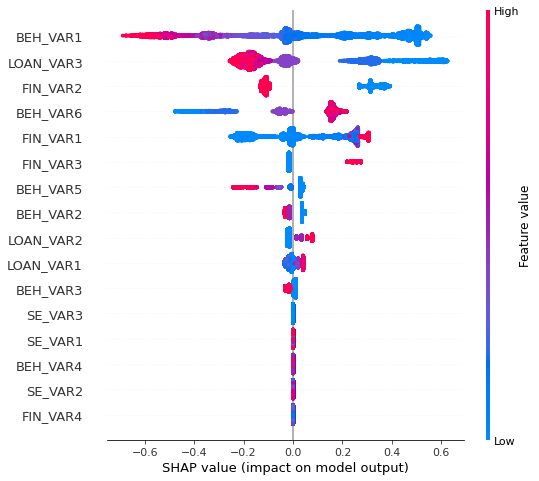

In [21]:
shap.summary_plot(shap_values, X_train)

Here, it is important to make economic sense of how each feature affects the final prediction. If the behaviour does not respond to an economic logic, we should remove the feature and retrain the model. 

If a client were to ask why a certain decision was made about his application we could use the SHAP values to get an idea of which factors the model took into account to approve or reject its application. Let us see an example.

In [22]:
pos = 625
x_i = X_test.iloc[[pos]]
shap_values = explainer(x_i)
Y_test.iloc[[pos]]
print(prob_test[pos])

0.9698168


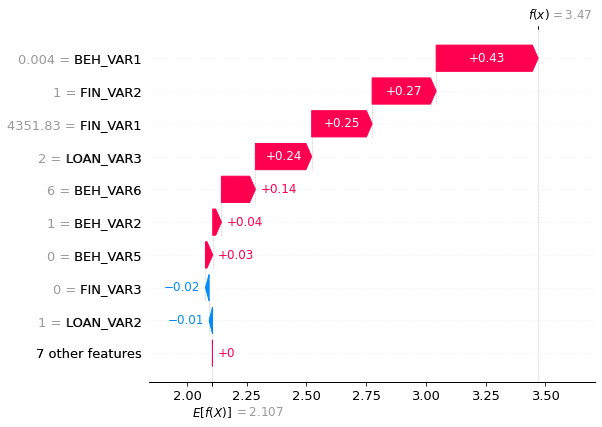

In [23]:
shap.plots.waterfall(shap_values[0])

# Deciding the optimal threshold

We use the validation set to find the optimal threshold. The criteria we will use will be the following: "From those thresholds the default rate of the approved loans do not exceed 5%, we will choose the one with higher approval rate". This matches well the balance we want to find between automating the most amount of loans while not taking excessive risk. The % of default rate tolerated will vary depending on the bank risk appetite.

In [24]:
thresholds = np.linspace(0.7, 1, 250)

rows = []

for t in thresholds:
    resultado = compute_metrics(X_val, Y_val, base_xgb, t)
    rows.append(resultado)

df_metricas = pd.DataFrame(rows, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])

In [25]:
df_metricas_filtered = df_metricas.sort_values('approvalRate', ascending=False)
df_metricas_filtered = df_metricas_filtered[df_metricas_filtered['TMO']< 0.05]
df_metricas_filtered.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
165,0.898795,0.049122,0.556909,0.592493,0.950878,0.257519,0.407507
166,0.900000,0.047636,0.549121,0.585121,0.952364,0.246241,0.414879
167,0.901205,0.046829,0.541534,0.577525,0.953171,0.238722,0.422475
168,0.902410,0.047103,0.534145,0.569482,0.952897,0.236842,0.430518
169,0.903614,0.046899,0.527955,0.563003,0.953101,0.233083,0.436997


In [26]:
best_threshold = df_metricas_filtered.iloc[0,0]

# Performance on the test set

In [27]:
rows_test = []
resultado = compute_metrics(X_test, Y_test, base_xgb, best_threshold)
rows_test.append(resultado)

df_metricas_test = pd.DataFrame(rows_test, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])
df_metricas_test.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
0,0.898795,0.052012,0.564094,0.599804,0.947988,0.270531,0.400196


With the threshold we picked using the validation dataset, the bank approves automatically 56,4% of the loans. This represents 60% of the good aplicants. 

# Fairness Metrics

To analyze possible biases, we will use the fairlearn library.

In [28]:
metrics = {
    "N": lambda y_true, y_pred: len(y_true),
    "Default_rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}

mf1 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF1_test
)

mf2 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF2_test
)

# Check the combination of features, this is called intersectional fairness, 
# it could happen that at group level the model is fair
# but when considering the combination of protected features we might detect bias
intersectional_fairness = pd.DataFrame({"PF1": PF1_test, "PF2": PF2_test})

mf12 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= intersectional_fairness
)

Fairness Metrics grouped by Protected Feature 1

In [29]:
mf1.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF1,,,,,,,,,
0,2522,0.048433,0.600317,0.951567,0.586995,0.556701,0.276423,0.413005,0.723577
1,3204,0.0547645,0.624532,0.945235,0.61011,0.569913,0.266667,0.38989,0.733333


In [30]:
mf1.ratio()

N                 0.787141
Default_rate      0.884387
Accuracy          0.961228
Precision         0.993346
Recall            0.962114
Selection_rate    0.976818
FPR               0.964706
FNR               0.944033
Specificity       0.986696
dtype: object

Fairness Metrics grouped by Protected Feature 2

In [31]:
mf2.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF2,,,,,,,,,
0,3484,0.0524635,0.661022,0.947536,0.660834,0.629162,0.337243,0.339166,0.662757
1,2242,0.0510597,0.540589,0.94894,0.502039,0.462979,0.189286,0.497961,0.810714


In [32]:
mf2.ratio()

N                 0.643513
Default_rate      0.973243
Accuracy          0.817808
Precision         0.998521
Recall            0.759705
Selection_rate    0.735867
FPR               0.561273
FNR                0.68111
Specificity       0.817497
dtype: object

Fairness Metrics grouped by the intersections of both protected features

In [33]:
mf12.by_group.head()

N Default_rate  Accuracy Precision    Recall Selection_rate  \
PF1 PF2                                                                   
0   0    1609    0.0502513  0.643257  0.949749  0.643295       0.618397   
    1     913    0.0440098  0.524644   0.95599  0.484511       0.447974   
1   0    1875    0.0543024  0.676267  0.945698  0.676225         0.6384   
    1    1329    0.0556439  0.551543  0.944356  0.514286       0.473288   

              FPR       FNR Specificity  
PF1 PF2                                  
0   0    0.357143  0.356705    0.642857  
    1    0.169811  0.515489    0.830189  
1   0    0.323383  0.323775    0.676617  
    1    0.201149  0.485714    0.798851

In [34]:
mf12.ratio()

N                 0.486933
Default_rate      0.790919
Accuracy          0.775795
Precision          0.98783
Recall            0.716493
Selection_rate    0.701713
FPR               0.475472
FNR               0.628093
Specificity       0.774351
dtype: object